In [1]:
# DAY 2: EXPLORATORY DATA ANALYSIS (IMPROVED)
# UCI Heart Disease Prediction
# PURPOSE:
#   - Visualize data distributions
#   - Analyze correlations
#   - Identify patterns and outliers
#   - Generate EDA report

import pandas as pd
import numpy as np
import os
import json
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:

# SECTION 1: LOAD DATA

print("LOADING DATA FOR EDA")

df = pd.read_csv(
    'data/heart_disease_uci.csv',
    na_values='?'
)
# Convert numeric columns safely
numeric_convert_cols = [
    'age', 'trestbps', 'chol',
    'thalch', 'oldpeak', 'ca', 'num'
]

for col in numeric_convert_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"✓ Data loaded: {df.shape[0]} rows × {df.shape[1]} columns")


LOADING DATA FOR EDA
✓ Data loaded: 920 rows × 16 columns


In [3]:
# SECTION 2: IDENTIFY FEATURE TYPES

print("FEATURE CLASSIFICATION")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.columns[~df.columns.isin(numeric_cols)].tolist()

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

target_col = 'num'


FEATURE CLASSIFICATION

Numeric columns (8): ['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']
Categorical columns (8): ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


TARGET VARIABLE DISTRIBUTION


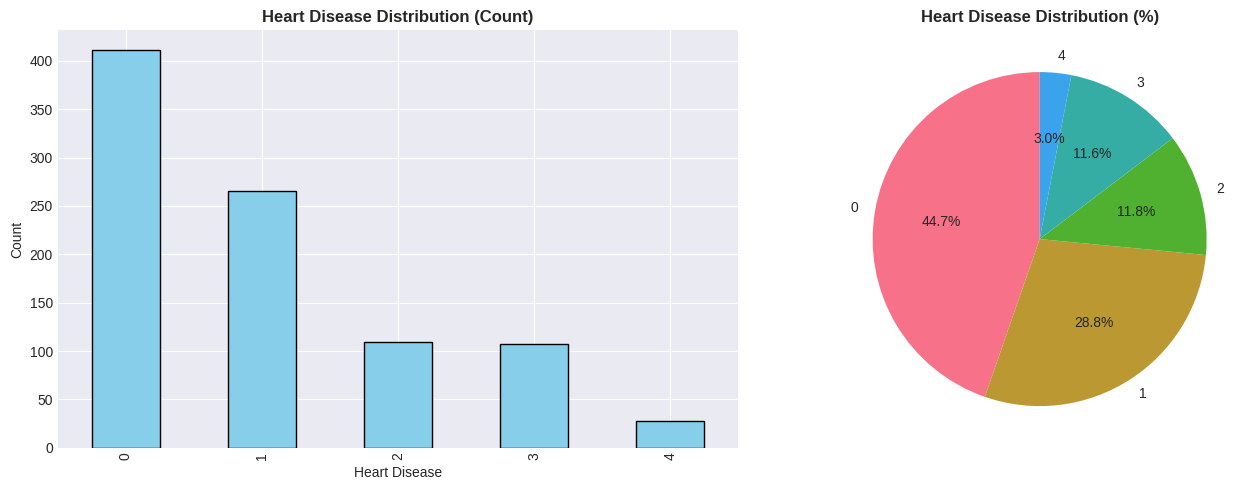

In [4]:
# SECTION 3: TARGET VARIABLE DISTRIBUTION

print("TARGET VARIABLE DISTRIBUTION")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
df[target_col].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='skyblue', edgecolor='black'
)
axes[0].set_title('Heart Disease Distribution (Count)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Heart Disease')
axes[0].set_ylabel('Count')

# Pie plot
df[target_col].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Heart Disease Distribution (%)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()


In [5]:
fig.savefig(
    'outputs/visualizations/day2_target_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: day2_target_distribution.png")

plt.show()
plt.close(fig)

✓ Saved: day2_target_distribution.png


NUMERIC FEATURES DISTRIBUTION


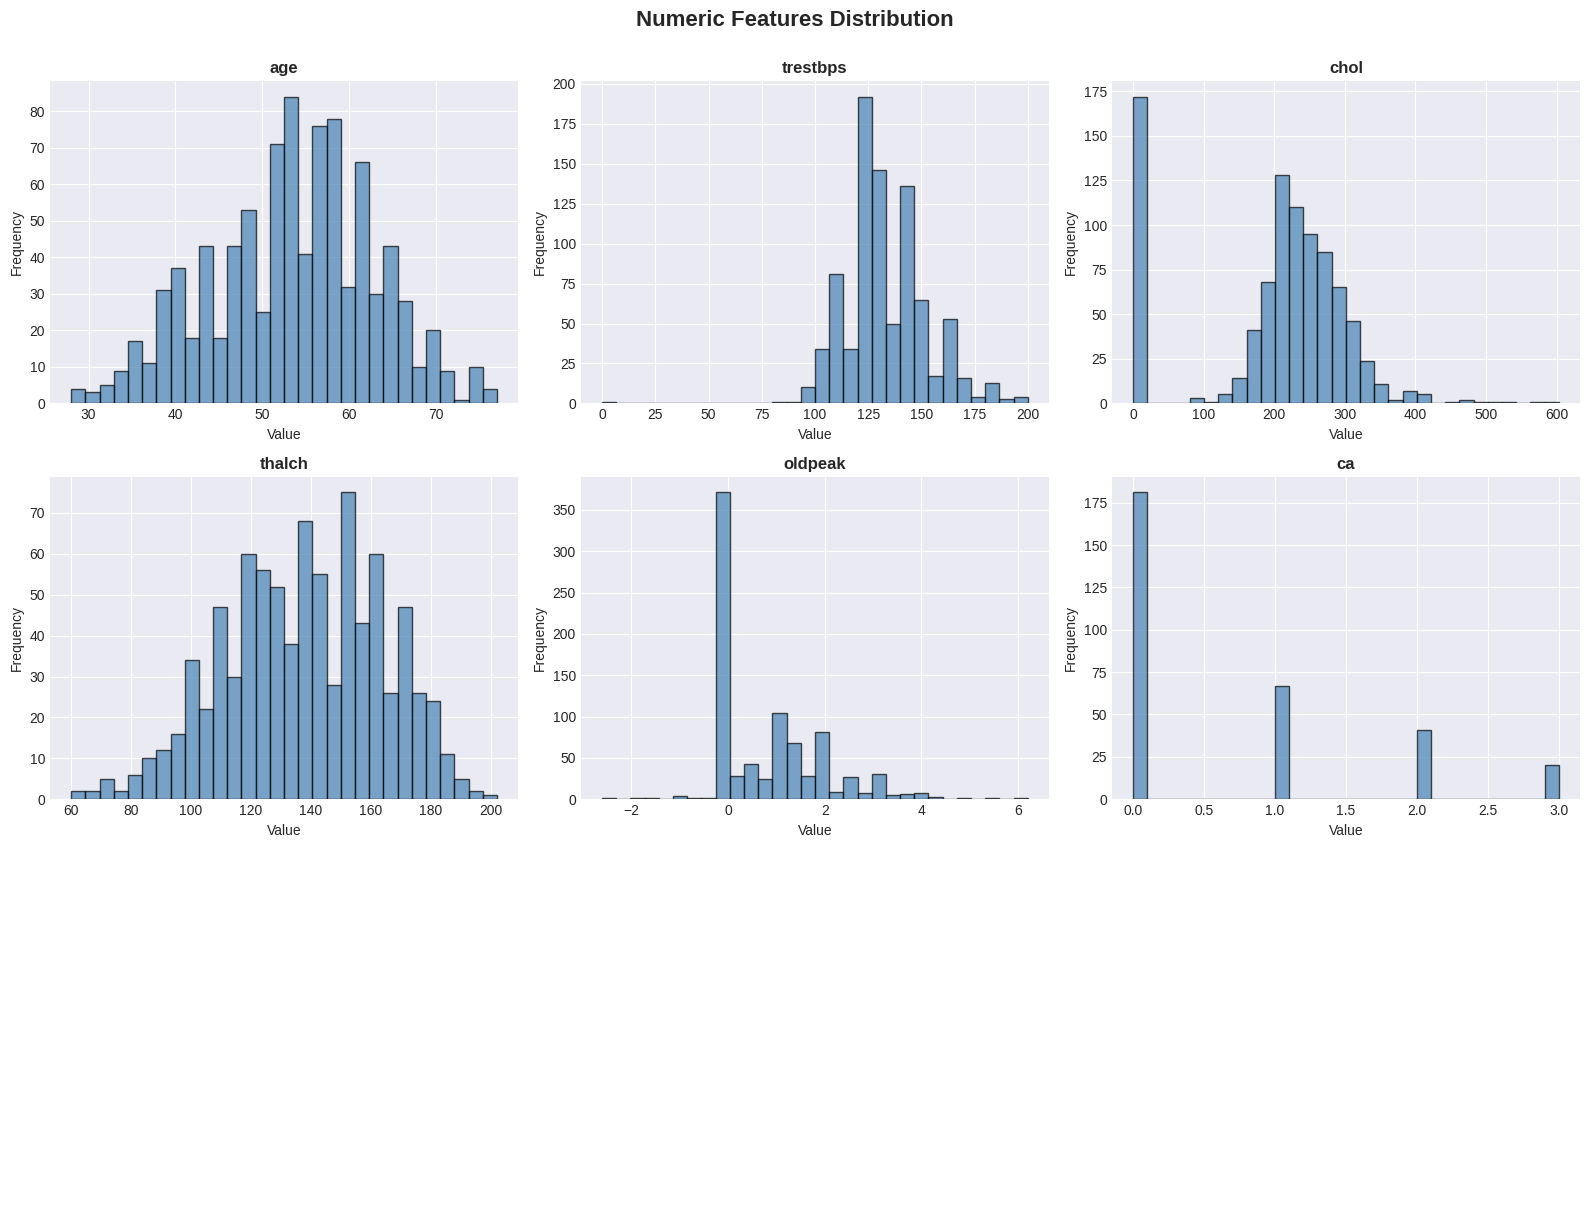

In [6]:
# SECTION 4: NUMERIC FEATURES DISTRIBUTION

print("NUMERIC FEATURES DISTRIBUTION")

# Select numeric features (exclude ID and target)
plot_cols = [col for col in numeric_cols if col not in ['id', target_col]]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(plot_cols):
    axes[idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

# Hide empty subplots
for idx in range(len(plot_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Numeric Features Distribution', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()



In [7]:
fig.savefig(
    'outputs/visualizations/day2_numeric_distributions.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: day2_numeric_distributions.png")

plt.show()
plt.close(fig)

✓ Saved: day2_numeric_distributions.png


CORRELATION ANALYSIS


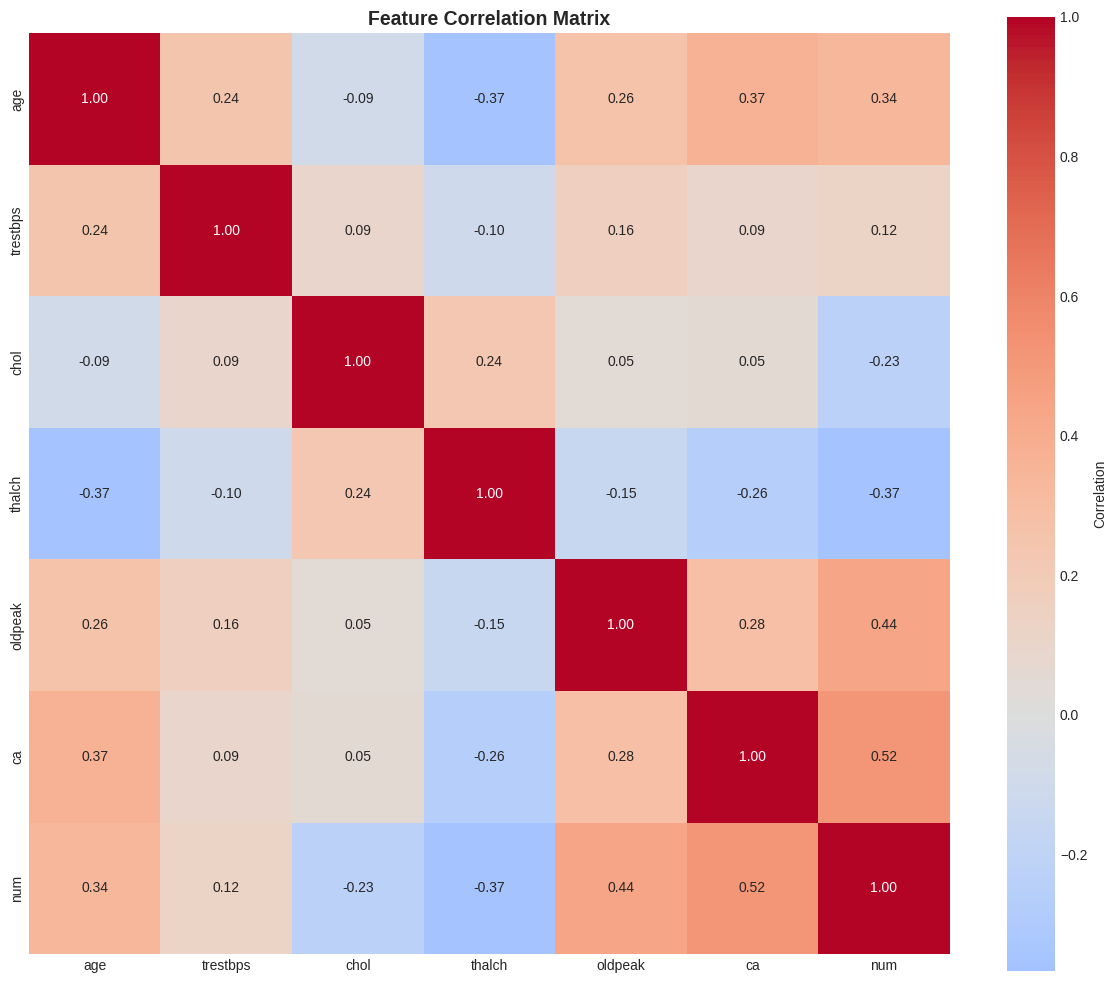

In [8]:
# SECTION 5: CORRELATION ANALYSIS

print("CORRELATION ANALYSIS")

# Create correlation matrix (numeric features only)
corr_cols = [col for col in numeric_cols if col not in ['id']]
corr_matrix = df[corr_cols].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()


In [9]:
fig.savefig(
    'outputs/visualizations/day2_correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: day2_correlation_heatmap.png")

plt.show()
plt.close(fig)

# Print top correlations with target
print(f"\nTop Correlations with {target_col}:")
if target_col in df.columns and df[target_col].dtype in [np.int64, np.float64]:
   target_corr = corr_matrix[target_col].sort_values(ascending=False)
for feature, corr_val in target_corr.items():
        if feature != target_col:
            print(f"  • {feature:20s}: {corr_val:7.4f}")

✓ Saved: day2_correlation_heatmap.png

Top Correlations with num:
  • ca                  :  0.5162
  • oldpeak             :  0.4431
  • age                 :  0.3396
  • trestbps            :  0.1223
  • chol                : -0.2315
  • thalch              : -0.3663


OUTLIER DETECTION


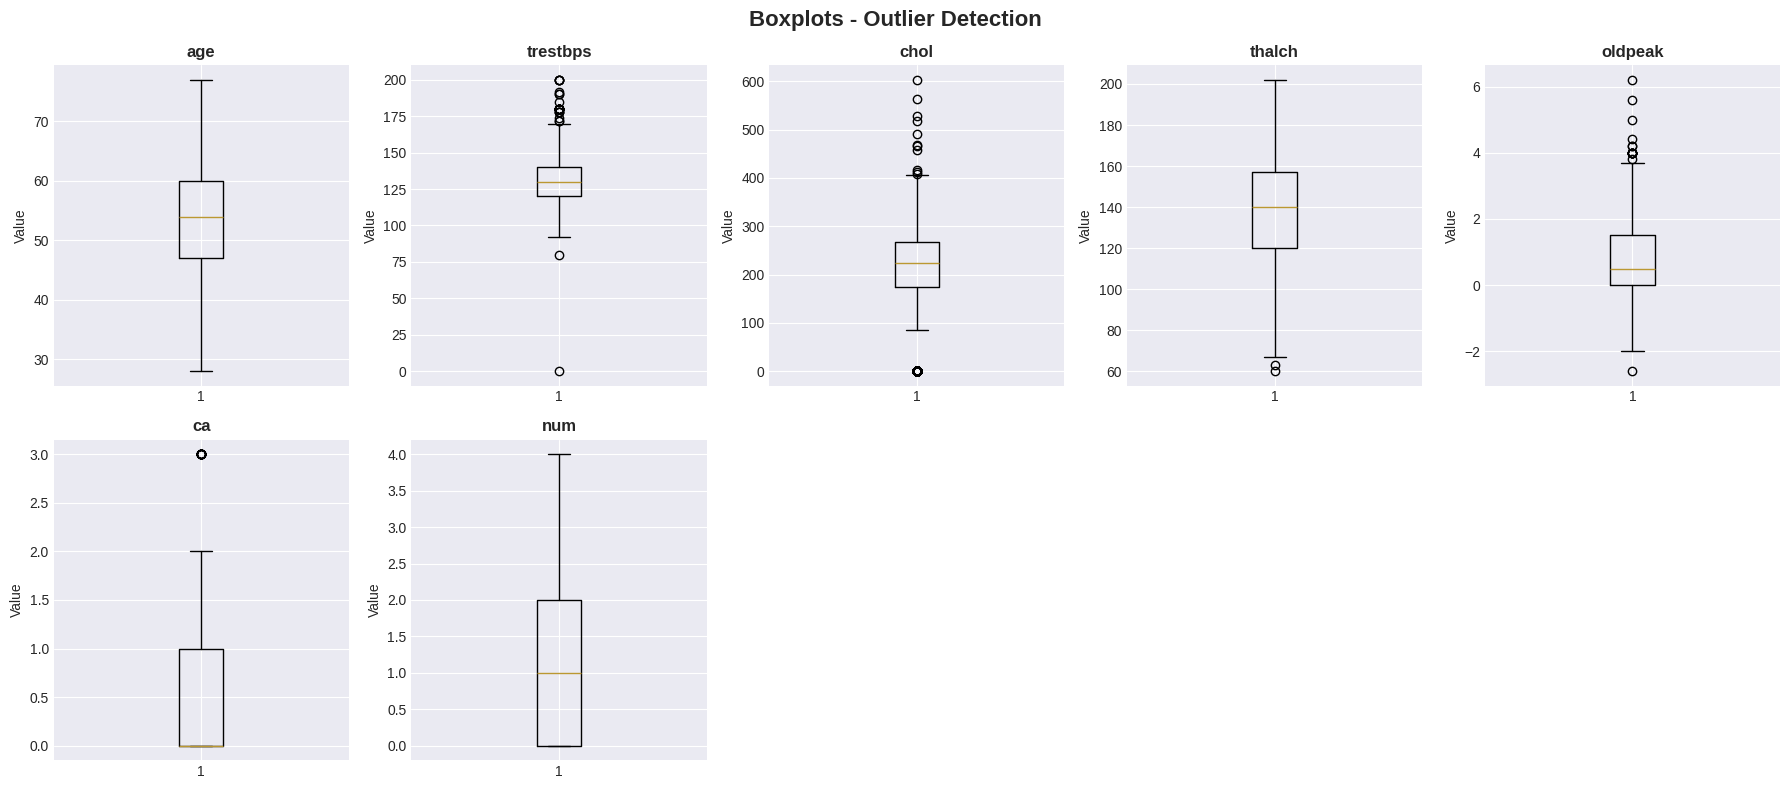

In [10]:
# SECTION 6: BOXPLOTS FOR OUTLIER DETECTION

print("OUTLIER DETECTION")

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(corr_cols[:10]):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].set_ylabel('Value')

for idx in range(len(corr_cols[:10]), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Boxplots - Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()


In [11]:
fig.savefig(
    'outputs/visualizations/day2_boxplots.png',
    dpi=300,
    bbox_inches='tight'
)

print("✓ Saved: day2_boxplots.png")

plt.show()
plt.close(fig)

✓ Saved: day2_boxplots.png


CATEGORICAL FEATURES ANALYSIS


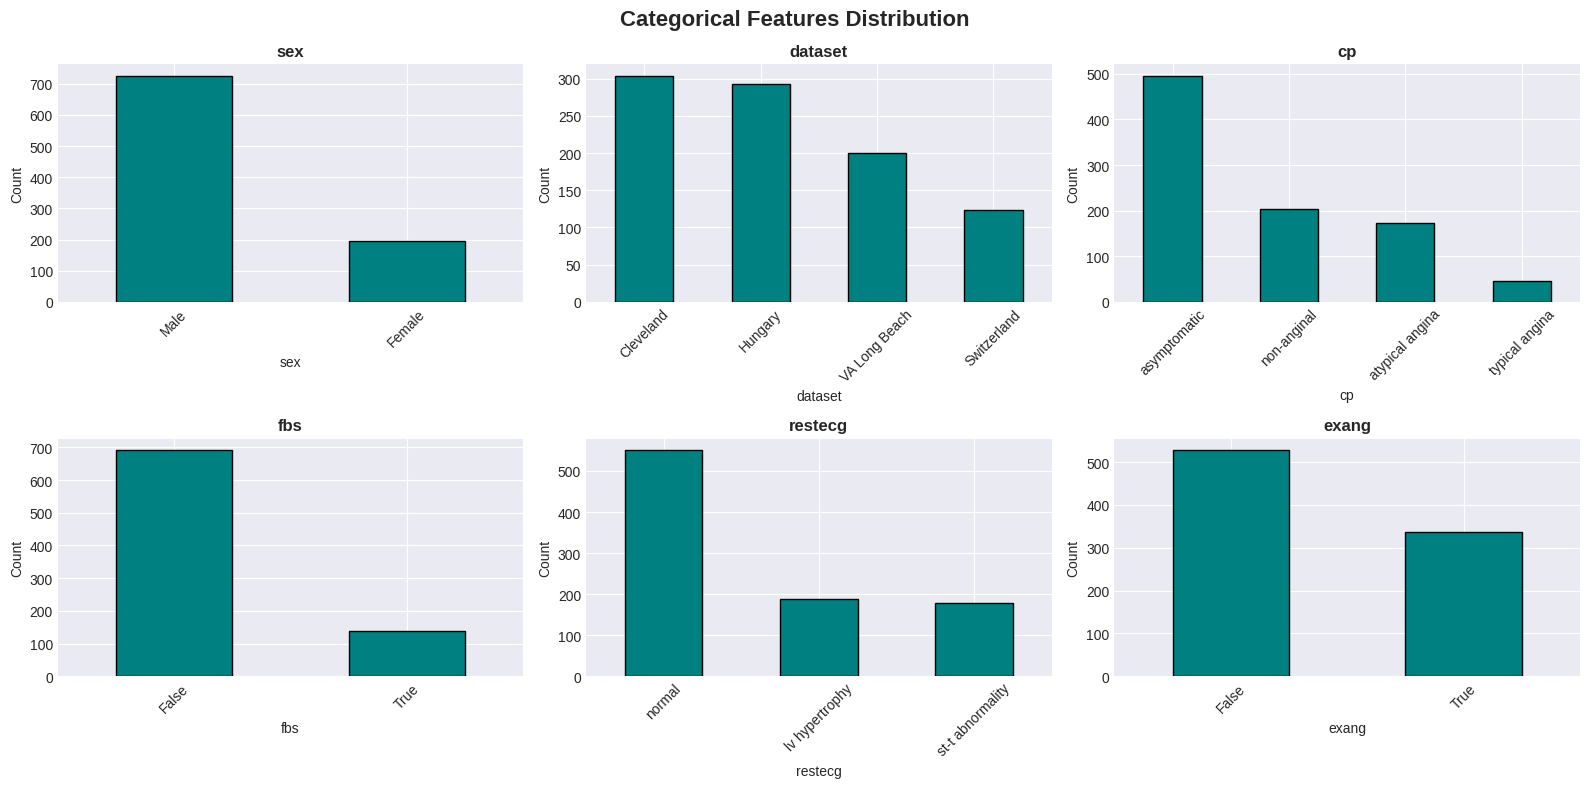

In [12]:
# SECTION 7: CATEGORICAL FEATURES ANALYSIS

print("CATEGORICAL FEATURES ANALYSIS")

if len(categorical_cols) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, col in enumerate(categorical_cols[:6]):
        df[col].value_counts().plot(kind='bar', ax=axes[idx], color='teal', edgecolor='black')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
    
    for idx in range(len(categorical_cols[:6]), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold')
    plt.tight_layout()
    


In [13]:
fig.savefig('outputs/visualizations/day2_categorical_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: day2_categorical_distribution.png")
plt.close()

✓ Saved: day2_categorical_distribution.png


In [14]:
# SECTION 8: GENERATE EDA SUMMARY REPORT

print("GENERATING EDA REPORT")

eda_summary = {
    'eda_date': datetime.now().isoformat(),
    'dataset_overview': {
        'total_rows': int(df.shape[0]),
        'total_columns': int(df.shape[1]),
        'numeric_features': len(numeric_cols),
        'categorical_features': len(categorical_cols)
    },
    'target_variable': {
        'name': target_col,
        'distribution': df[target_col].value_counts().to_dict(),
        'class_balance': {
            str(k): round(v/len(df)*100, 2) 
            for k, v in df[target_col].value_counts().items()
        }
    },
    'binary_target_variable': {
        'description': '0=no disease, 1=disease (num values 1-4 collapsed)',
        'distribution': (df[target_col] > 0).astype(int).value_counts().to_dict(),
        'class_balance': {
            str(k): round(v / len(df) * 100, 2)
            for k, v in (df[target_col] > 0).astype(int).value_counts().items()
        }
    },
    'missing_values': {
        col: int(df[col].isnull().sum()) 
        for col in df.columns
    },
    'numeric_statistics': {
        col: {
            'min': float(df[col].min()),
            'max': float(df[col].max()),
            'mean': float(df[col].mean()),
            'median': float(df[col].median()),
            'std': float(df[col].std())
        }
        for col in numeric_cols
    },
    'outliers_detected': True if any(df[col].nunique() > 10 for col in numeric_cols) else False
}

os.makedirs('outputs/reports', exist_ok=True)
with open('outputs/reports/day2_eda_report.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)

print("✓ Saved: day2_eda_report.json")

GENERATING EDA REPORT
✓ Saved: day2_eda_report.json
